In [1]:
# Finite Differences comparison

In [6]:
include("../src/main.jl")
println("Available threads: ", nthreads())
println("RHO_unit:", RHO_unit)

Available threads: 1
RHO_unit:3.906325282703709e-19


In [7]:
#dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
dump_filepath = "../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

"../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [8]:
#TODO: put this in reading file
const N1 = 288
const N2 = 128
const N3 = 128

const METRIC = "MKS" #FMKS or MKS TODO: prob have to be read from file
trat_large = 20. #TODO: prob have to be read from file
const trat_small = 1. #TODO: prob have to be read from file
const beta_crit = 1.0 #TODO: prob have to be read from file
const game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
const gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
const gam = (1.444444)  # Total adiabatic index TODO: prob have to be read from file
const Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
const rmin_geo = 1.00187575798832   #TODO: Has to be read from file as Rin and compared to the value chosen
const rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
const th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
const sigma_cut = 1.0 #TODO: maybe put it somewhere else?
const sigma_cut_high = -1.0
const startx::MVec4 = [0, 1.635684465252566e-01, 0, 0]#TODO: prob have to be read from file
const stopx::MVec4 = [1,  6.907755278982137, 1, 2 * π]#TODO: prob have to be read from file
const dx::MVec4 =[0, 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02]
const bhspin = 0.9375 #TODO: prob have to be read from file
const hslope = 0.3 #TODO: prob have to be read from file


0.3

In [9]:
const simulation_data = load_data(dump_filepath, trat_large);

Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [10]:
#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const pixels_x = 80
const pixels_y = 80
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
#const cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0
const nmaxstep = 15000


15000

In [14]:
include("../src/main.jl")
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
const nx, ny = pixels_x, pixels_y
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_dRhigh_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX =DXsize
const DY = DYsize
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)

# Pre-allocate trajectory arrays for each thread
num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, (num_threads+1))
for tid in 1:(num_threads + 1)
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny
p = Progress(
    total; 
    desc = "Computing Image and Sensitivity...", 
    showspeed = true, 
    barlen = 30
)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_dRhigh_out = Ref{Float64}(0.0)
        
        AutoDiffGeoTrajEulerMethod_GRMHD!(
            thread_trajs[tid], dI_dθo_out, intensity_out, dI_dRhigh_out,
            ro, th, phi, bhspin, nx, ny, nmaxstep, i, j, 
            freq, fovx, fovy, Rout, Rstop, simulation_data
        )
        
        dI_dRhigh_arr[i + 1, j + 1] = dI_dRhigh_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]

        # Update the progress bar
        ProgressMeter.next!(
            p; 
            showvalues = [
                (:thread_id, tid), 
                (:pixel, "($i, $j)"), 
                (:total_done, "$(i*ny + j)/$total")
            ]
        )
    end
end

finish!(p)

j nan in Leung fit: j NaN f 6.3057295957512245e10 x 6.299750629906625e10 nu 9.43693118588338e13 nus 1497.984879128978 nuc 2.79925054224516e6 K2 1.6248388986351774 Thetae 1.0
j nan in Leung fit: j Dual{ForwardDiff.Tag{var"#jar_calc##16#jar_calc##17"{Float64, Float64, Float64, Float64, Float64}, Float64}}(NaN,NaN) f Dual{ForwardDiff.Tag{var"#jar_calc##16#jar_calc##17"{Float64, Float64, Float64, Float64, Float64}, Float64}}(6.3057295957512245e10,-1.2607472268968666e11) x Dual{ForwardDiff.Tag{var"#jar_calc##16#jar_calc##17"{Float64, Float64, Float64, Float64, Float64}, Float64}}(6.299750629906625e10,-1.259950125981325e11) nu 9.43693118588338e13 nus Dual{ForwardDiff.Tag{var"#jar_calc##16#jar_calc##17"{Float64, Float64, Float64, Float64, Float64}, Float64}}(1497.984879128978,2995.969758257956) nuc 2.79925054224516e6 K2 Dual{ForwardDiff.Tag{var"#jar_calc##16#jar_calc##17"{Float64, Float64, Float64, Float64, Float64}, Float64}}(1.6248388986351774,3.851585027467589) Thetae Dual{ForwardDiff.Tag{

┌ Error: Invalid intensity computed
│   If = Dual{ForwardDiff.Tag{var"#AutoDiffGeoTrajEulerMethod_GRMHD!##68#AutoDiffGeoTrajEulerMethod_GRMHD!##69"{Vector{OfTraj}, Float64, Float64, Vector{IharmData}, MVector{4, Float64}, MVector{4, Float64}, MVector{4, Float64}, MVector{4, Float64}, Int64}, Float64}}(NaN,NaN)
└ @ Main ~/Jipole/src/radiation.jl:224


LoadError: TaskFailedException

[91m    nested task error: [39mInvalid intensity computed: Dual{ForwardDiff.Tag{var"#AutoDiffGeoTrajEulerMethod_GRMHD!##68#AutoDiffGeoTrajEulerMethod_GRMHD!##69"{Vector{OfTraj}, Float64, Float64, Vector{IharmData}, MVector{4, Float64}, MVector{4, Float64}, MVector{4, Float64}, MVector{4, Float64}, Int64}, Float64}}(NaN,NaN)
    Stacktrace:
      [1] [0m[1merror[22m[0m[1m([22m[90ms[39m::[0mString[0m[1m)[22m
    [90m    @[39m [90mBase[39m [90m./[39m[90m[4merror.jl:44[24m[39m
      [2] [0m[1mapproximate_solve[22m[0m[1m([22m[90mIi[39m::[0mDual[90m{ForwardDiff.Tag{var"#AutoDiffGeoTrajEulerMethod_GRMHD!##68#AutoDiffGeoTrajEulerMethod_GRMHD!##69"{Vector{OfTraj}, Float64, Float64, Vector{IharmData}, MVector{4, Float64}, MVector{4, Float64}, MVector{4, Float64}, MVector{4, Float64}, Int64}, Float64}, Float64, 1}[39m, [90mji[39m::[0mFloat64, [90mki[39m::[0mFloat64, [90mjf[39m::[0mFloat64, [90mkf[39m::[0mFloat64, [90m

# dI_dth_FD, Img_FD = FiniteDifferencesθ(ro, th, phi, DXsize, DYsize, nx, ny, SourceD, freq, 15000, 1e-6, bhspin, Rout, Rstop, simulation_data)

NMSE: NaN


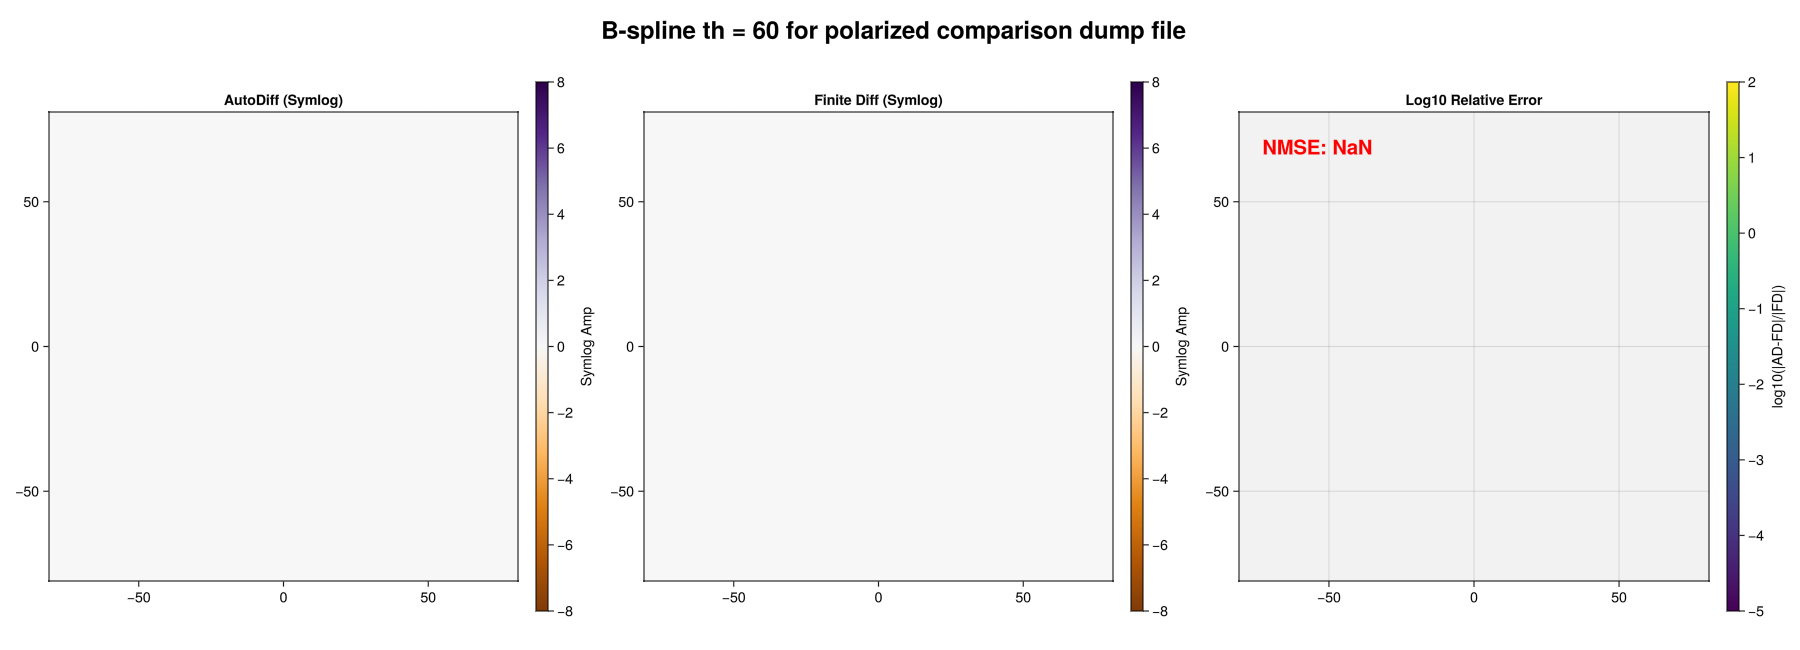

In [8]:
using GLMakie
using Statistics

# -----------------------------
# 0. Physics & Coordinates Setup
# -----------------------------
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# 1. Symlog Transformation
# -----------------------------
function symlog(x, linthresh)
    absx = abs(x)
    if absx <= linthresh
        return x / linthresh
    else
        return sign(x) * (1 + log10(absx / linthresh))
    end
end

linthresh = 1e-7 
dI_AD_sym = symlog.(dI_dθo_arr, linthresh)
dI_FD_sym = symlog.(dI_dth_FD, linthresh)

# -----------------------------
# 2. Simple Relative Error
# -----------------------------
rel_err = abs.(dI_dθo_arr .- dI_dth_FD) ./ abs.(dI_dth_FD)
log_rel_err = log10.(rel_err)

# -----------------------------
# 2.5 NMSE Calculation
# -----------------------------
# mse = np.sum((img1 - img2)**2)
# reference_energy = np.sum(img2**2)
# nmse = mse / reference_energy

# Note: We filter(isfinite, ...) to ensure NaNs in the background don't ruin the sum
diff_sq = (dI_dθo_arr .- dI_dth_FD).^2
ref_sq  = dI_dth_FD.^2

mse = sum(filter(isfinite, diff_sq))
ref_energy = sum(filter(isfinite, ref_sq))
nmse = mse / ref_energy

# Prepare string for plotting
nmse_str = "NMSE: $(round(nmse, sigdigits=4))"
println(nmse_str)

# -----------------------------
# 3. Plotting
# -----------------------------
# Increased height to fit the bottom label
fig = Figure(size = (1800, 650)) 

# --- Main Title ---
Label(fig[0, 1:6], "B-spline th = 60 for polarized comparison dump file", 
      fontsize = 24, font = :bold)

# Shared limits
max_sym = 8

# --- Plot 1: AutoDiff ---
ax1 = Axis(fig[1, 1], title = "AutoDiff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm1 = heatmap!(ax1, x_coords, y_coords, dI_AD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym)) 
Colorbar(fig[1, 2], hm1, label = "Symlog Amp")

# --- Plot 2: Finite Diff ---
ax2 = Axis(fig[1, 3], title = "Finite Diff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_FD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym))
Colorbar(fig[1, 4], hm2, label = "Symlog Amp")

# --- Plot 3: Relative Error ---
ax3 = Axis(fig[1, 5], title = "Log10 Relative Error", aspect = 1, backgroundcolor=:gray95)
hm3 = heatmap!(ax3, x_coords, y_coords, log_rel_err, 
    colormap = :viridis, colorrange = (-5, 2))
Colorbar(fig[1, 6], hm3, label = "log10(|AD-FD|/|FD|)")
# Print NMSE directly onto the Relative Error axis (top-left corner)
text!(ax3, 0.05, 0.95, text = nmse_str, 
      space = :relative, align = (:left, :top), 
      fontsize = 20, font = :bold, color = :red)



fig

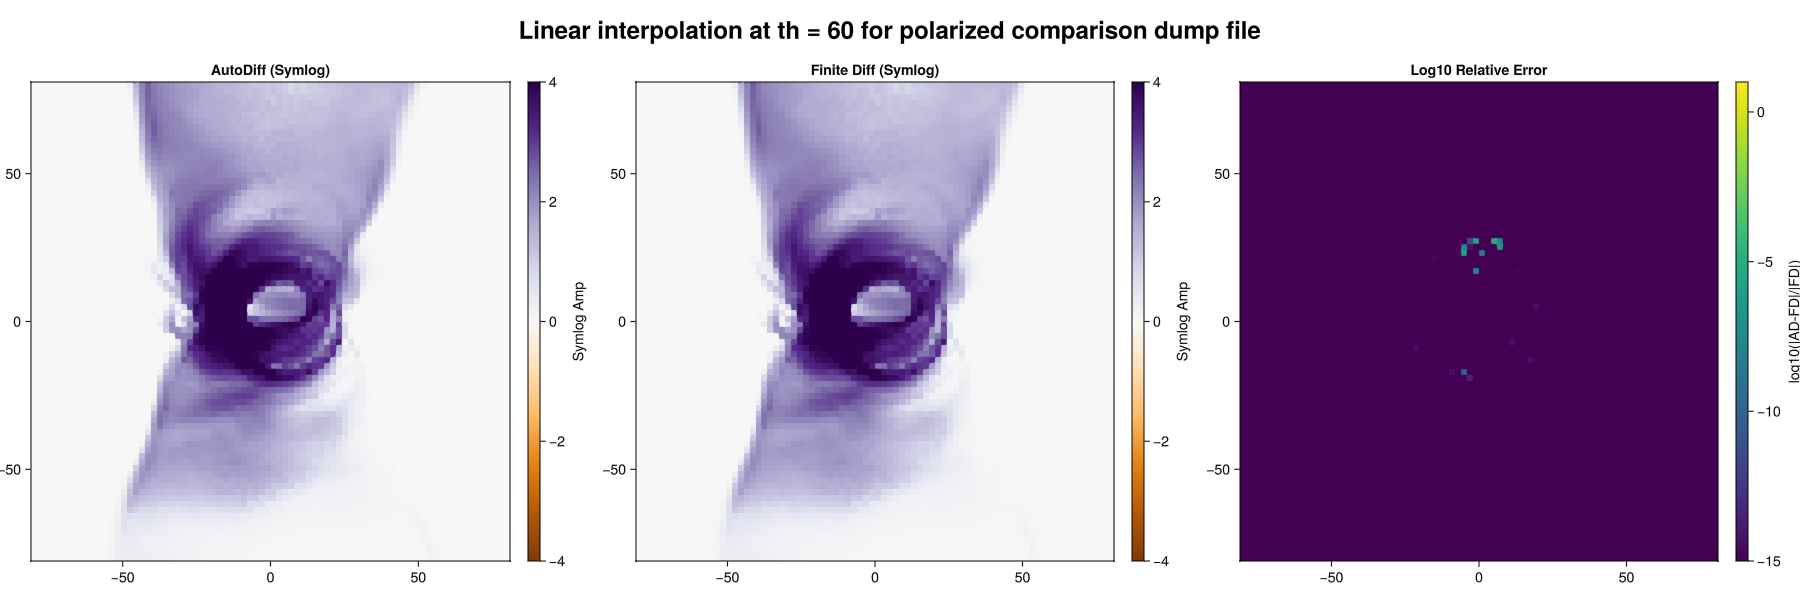

In [12]:
using GLMakie
using Statistics

# -----------------------------
# 0. Physics & Coordinates Setup
# -----------------------------
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# 1. Symlog Transformation
# -----------------------------
function symlog(x, linthresh)
    absx = abs(x)
    if absx <= linthresh
        return x / linthresh
    else
        return sign(x) * (1 + log10(absx / linthresh))
    end
end

linthresh = 1e-7 
dI_AD_sym = symlog.(I_arr, linthresh)
dI_FD_sym = symlog.(Img_FD, linthresh)

# -----------------------------
# 2. Simple Relative Error
# -----------------------------
rel_err = abs.(I_arr .- Img_FD) ./ abs.(Img_FD)
log_rel_err = log10.(rel_err)

# -----------------------------
# 3. Plotting
# -----------------------------
# Increased width to give panels room
fig = Figure(size = (1800, 600)) 

# --- Main Title ---
# Span across all 6 columns (3 plots + 3 colorbars)
Label(fig[0, 1:6], "Linear interpolation at th = 60 for polarized comparison dump file", 
      fontsize = 24, font = :bold)

# Shared limits
max_sym = 4

# --- Plot 1: AutoDiff ---
# Added backgroundcolor=:gray95 to see the plot extent clearly
ax1 = Axis(fig[1, 1], title = "AutoDiff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm1 = heatmap!(ax1, x_coords, y_coords, dI_AD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym)) 
Colorbar(fig[1, 2], hm1, label = "Symlog Amp")

# --- Plot 2: Finite Diff ---
ax2 = Axis(fig[1, 3], title = "Finite Diff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_FD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym))
Colorbar(fig[1, 4], hm2, label = "Symlog Amp")

# --- Plot 3: Relative Error ---
ax3 = Axis(fig[1, 5], title = "Log10 Relative Error", aspect = 1, backgroundcolor=:gray95)
hm3 = heatmap!(ax3, x_coords, y_coords, log_rel_err, 
    colormap = :viridis,
    colorrange = (-15, 1)) # <--- Set manually here
Colorbar(fig[1, 6], hm3, label = "log10(|AD-FD|/|FD|)")

# ---------------------------------------------------------
# LAYOUT FIX: Force columns 1, 3, and 5 to be equal squares
# ---------------------------------------------------------
for col in [1, 3, 5]
    colsize!(fig.layout, col, Aspect(1, 1.0))
end

fig